In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dropout, Flatten, Dense
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
WINDOW_SIZE = 40   # 2s a 20Hz
OVERLAP = 20       # 50%
TEST_SIZE = 0.2
EPOCHS = 15
BATCH_SIZE = 16


In [ ]:
archivo_caidas   = Path(r"Codigos_raspberry\datos_limpios\datos_capturados_caidas (1).csv")
archivo_normales = Path(r"Codigos_raspberry\datos_limpios\datos_capturados_normales.csv")

ARCHIVOS = {
    archivo_caidas: 1,     # caída
    archivo_normales: 0    # normal
}

COLUMNAS = ['ax', 'ay', 'az', 'gx', 'gy', 'gz']

datos_totales = []
etiquetas_totales = []

COLUMNAS = [
    'cadera_ax','cadera_ay','cadera_az','cadera_gx','cadera_gy','cadera_gz',
]

cols_giro = [
    'cadera_gx','cadera_gy','cadera_gz',
    'pierna_gx','pierna_gy','pierna_gz'
]

for archivo, etiqueta in ARCHIVOS.items():
    print(f"\n📄 Procesando: {archivo.name}")
    df = pd.read_csv(archivo)

    # Escalar giroscopio para dar mas prioridad al giroscopio
    df[cols_giro] *= 4.0

    for i in range(0, len(df) - WINDOW_SIZE + 1, OVERLAP):
        ventana = df.iloc[i:i+WINDOW_SIZE][COLUMNAS].values
        datos_totales.append(ventana)
        etiquetas_totales.append(etiqueta)


X = np.array(datos_totales, dtype=np.float32)
y = np.array(etiquetas_totales, dtype=np.int32)

unique, counts = np.unique(y, return_counts=True)
for clase, count in zip(unique, counts):
    nombre = "Normal" if clase == 0 else "Caída"



📄 Procesando: datos_capturados_caidas (1).csv

📄 Procesando: datos_capturados_normales.csv


In [5]:

#Train test y split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=42, stratify=y
)

In [6]:
#Modelo CNN 
model = Sequential([
    Conv1D(32, 3, activation='relu', padding='same', input_shape=(WINDOW_SIZE, 12)),
    MaxPooling1D(2),
    
    Conv1D(64, 3, activation='relu', padding='same'),
    MaxPooling1D(2),
    Dropout(0.4),
    
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    
    Dense(1, activation='sigmoid')
])
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

c:\Users\PC\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 32)         │         1,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 640)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 48,481 (189.38 KB)

 Trainable params: 48,481 (189.38 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
#Entrenar modelo
early_stop = EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[early_stop],
    verbose=1
)
loss, acc = model.evaluate(X_test, y_test)
print(f"\n Pérdida: {loss:.4f} | Precisión: {acc:.4f}")
# Predicciones
y_pred = (model.predict(X_test) > 0.5).astype(int)

Epoch 1/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.8578 - loss: 1.3002 - val_accuracy: 0.9502 - val_loss: 0.1327
Epoch 2/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9457 - loss: 0.1609 - val_accuracy: 0.9595 - val_loss: 0.0973
Epoch 3/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9599 - loss: 0.1120 - val_accuracy: 0.9678 - val_loss: 0.0758
Epoch 4/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9666 - loss: 0.0977 - val_accuracy: 0.9694 - val_loss: 0.0719
Epoch 5/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9705 - loss: 0.0829 - val_accuracy: 0.9738 - val_loss: 0.0658
Epoch 6/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9703 - loss: 0.0856 - val_accuracy: 0.9705 - val_loss: 0.0659
Epoch 7/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9678 - loss: 0.0975 - val_accuracy: 0.9645 - val_loss: 0.0775
Epoch 8/15
908/908 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.9740 - loss: 0.0675 - val_accuracy: 0.

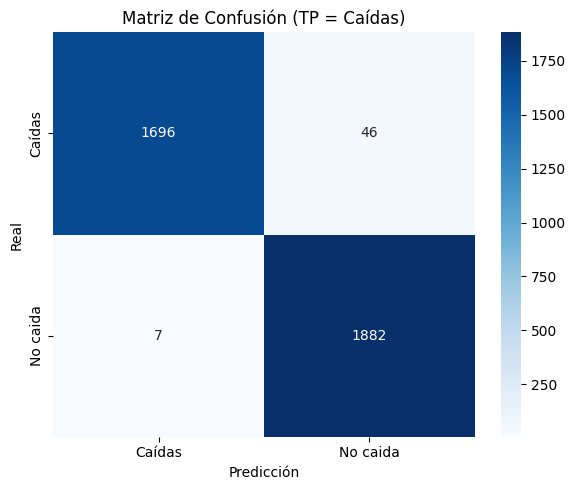

In [19]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Calcular matriz
cm = confusion_matrix(y_test, y_pred, labels=[1, 0])  # Primero la clase "Caída"

# Etiquetas
etiquetas = ['Caídas', 'No caida']

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=etiquetas,
            yticklabels=etiquetas)
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión (TP = Caídas)")
plt.tight_layout()
plt.savefig('matriz_confusion_caidas.png', dpi=150)
plt.show()

In [17]:
# Reporte
print("\n Reporte de clasificación:")
print(classification_report(y_test, y_pred, target_names=['Normal', 'Caída']))


 Reporte de clasificación:
              precision    recall  f1-score   support

      Normal       0.98      1.00      0.99      1889
       Caída       1.00      0.97      0.98      1742

    accuracy                           0.99      3631
   macro avg       0.99      0.98      0.99      3631
weighted avg       0.99      0.99      0.99      3631



In [10]:
#Guardar modelo
MODEL_PATH = "modelo_cnn_imu.h5"
model.save(MODEL_PATH)
print(f"\n💾 Modelo guardado: {MODEL_PATH}")


💾 Modelo guardado: modelo_cnn_imu.h5


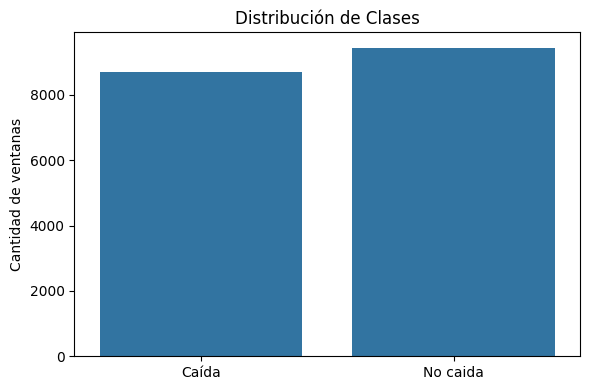

💾 Imagen guardada: class_distribution_caida_primero.png


In [25]:
# Distribución de clases con "Caída" primero
unique, counts = np.unique(y, return_counts=True)

# Reordenar: primero caídas (clase 1), luego normales (clase 0)
counts_reordenados = [counts[unique.tolist().index(1)], counts[unique.tolist().index(0)]]

plt.figure(figsize=(6,4))
sns.barplot(x=['Caída', 'No caida'], y=counts_reordenados)
plt.title("Distribución de Clases")
plt.ylabel("Cantidad de ventanas")
plt.tight_layout()
plt.savefig("class_distribution_caida_primero.png", dpi=150)
plt.show()
print("💾 Imagen guardada: class_distribution_caida_primero.png")


💾 Imagen guardada: confusion_matrix.png


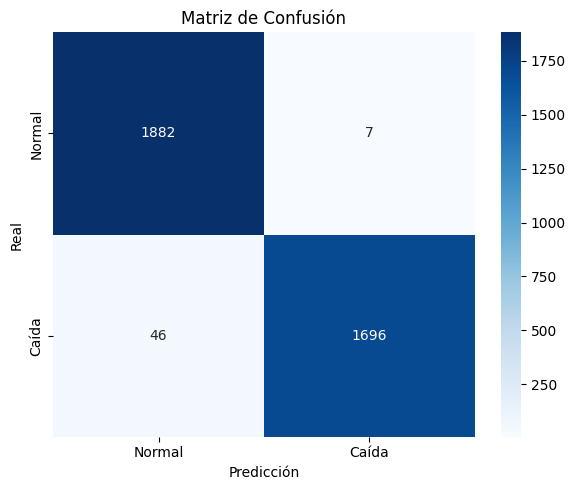

In [12]:

#matriz de confusion
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Caída'],
            yticklabels=['Normal', 'Caída'])
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.title("Matriz de Confusión")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150)
print("💾 Imagen guardada: confusion_matrix.png")

💾 Imagen guardada: training_metrics.png


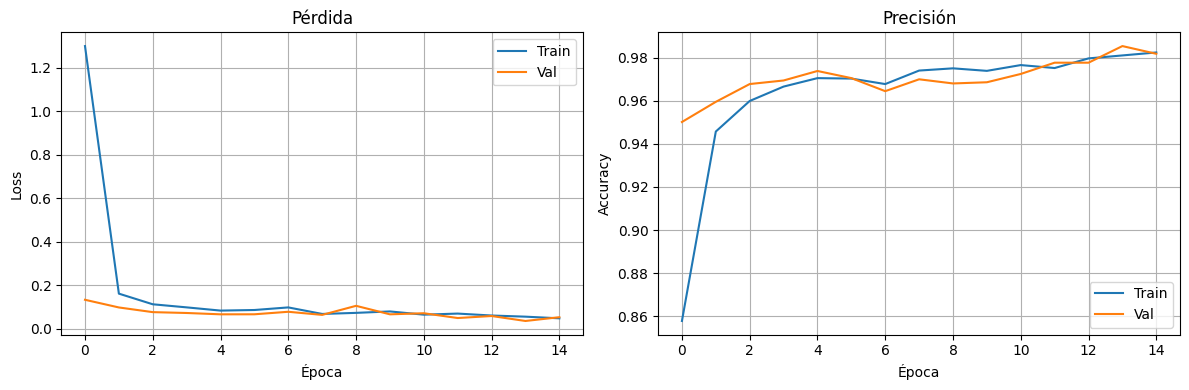

In [13]:
#Grafico entrenamiento
plt.figure(figsize=(12,4))

# Loss
plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Pérdida')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

# Accuracy
plt.subplot(1,2,2)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Precisión')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig("training_metrics.png", dpi=150)
print("💾 Imagen guardada: training_metrics.png")

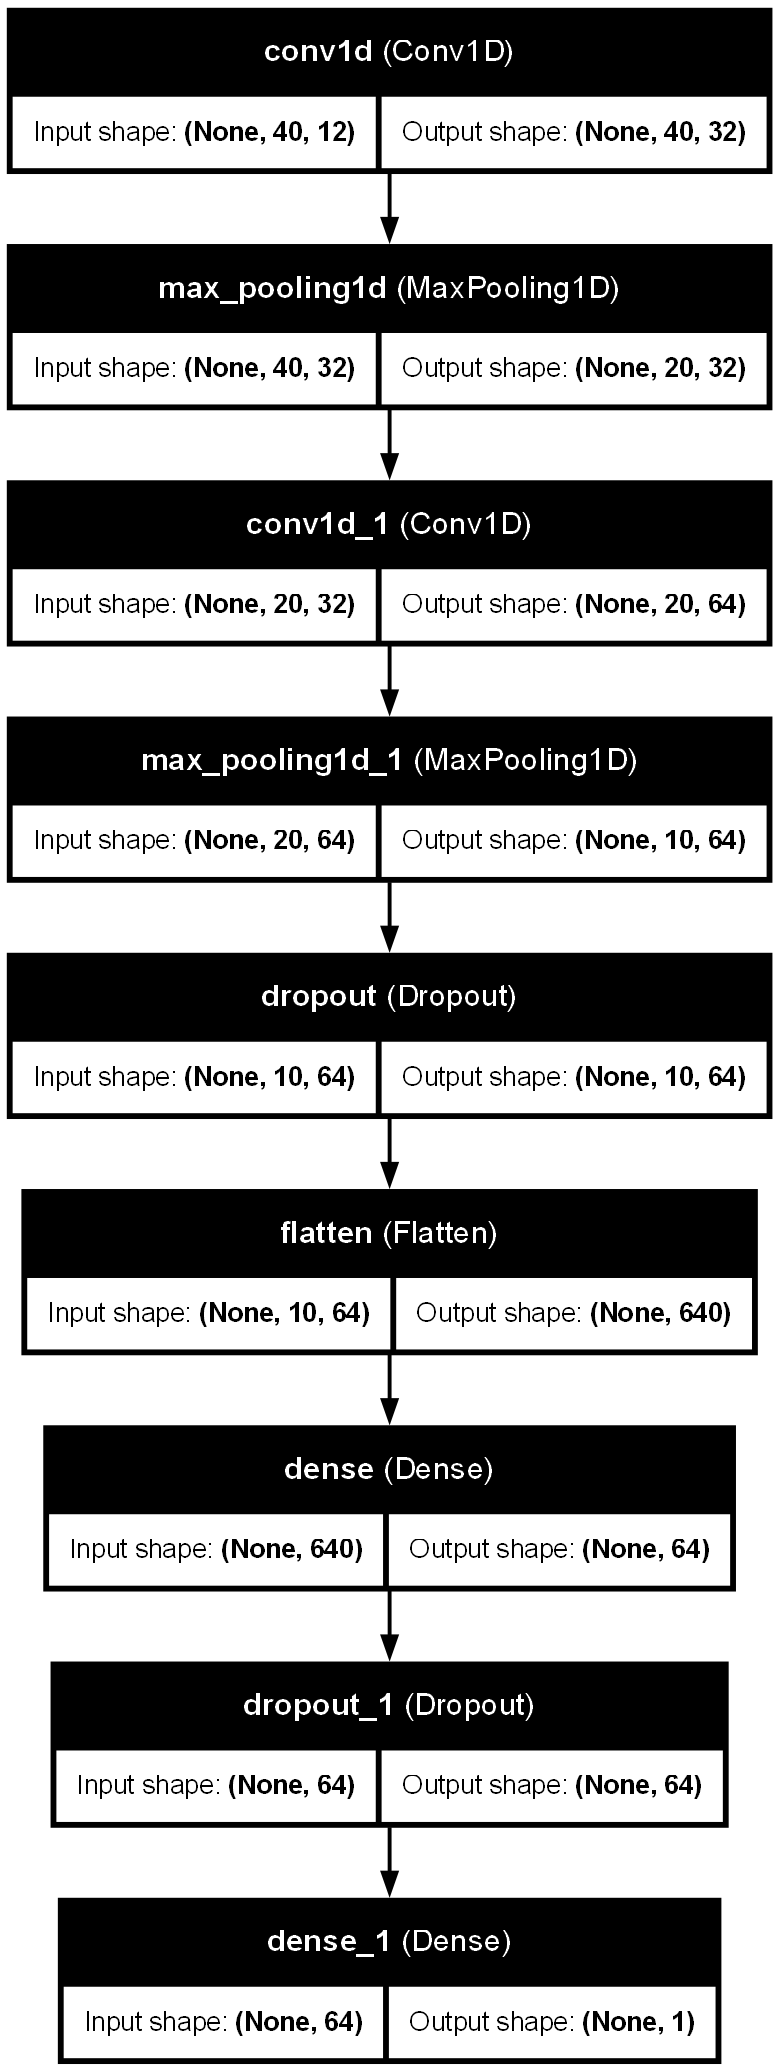

In [14]:
#Grafico de modelo
from tensorflow.keras.utils import plot_model

plot_model(
    model,
    to_file="arquitectura_cnn.png",
    show_shapes=True,
    show_layer_names=True,
    dpi=140
)

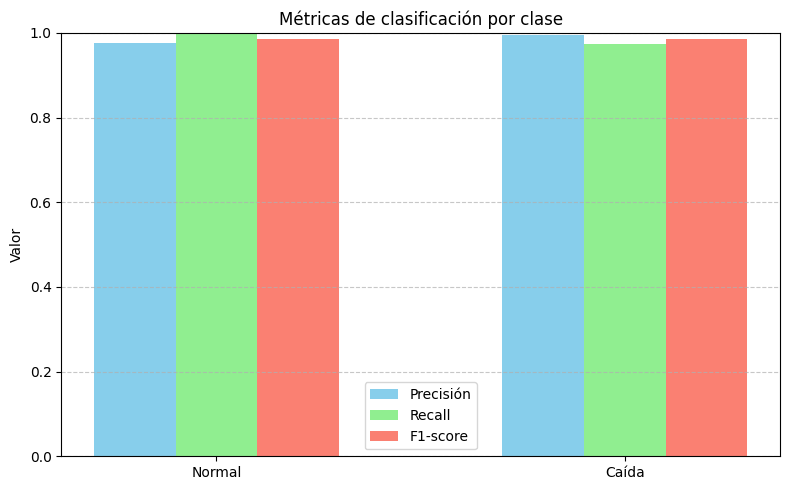

💾 Imagen guardada: metricas_clasificacion.png


In [16]:
from sklearn.metrics import precision_recall_fscore_support

# Obtener métricas
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred, average=None)

clases = ['Normal', 'Caída']

# Crear gráfico
x = np.arange(len(clases))  # posiciones en x
width = 0.2  # ancho de las barras

plt.figure(figsize=(8,5))
plt.bar(x - width, precision, width, label='Precisión', color='skyblue')
plt.bar(x, recall, width, label='Recall', color='lightgreen')
plt.bar(x + width, f1, width, label='F1-score', color='salmon')

plt.xticks(x, clases)
plt.ylim(0, 1)
plt.ylabel("Valor")
plt.title("Métricas de clasificación por clase")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()

# Guardar imagen
plt.savefig("metricas_clasificacion.png", dpi=150)
plt.show()
print("💾 Imagen guardada: metricas_clasificacion.png")